# Классификация городских эпидемических волн по форме синтетических кривых

Ноутбук идёт сверху вниз: сначала читаем синтетические SEIR-траектории, смотрим на них, извлекаем признаки формы и обучаем классификатор. Затем читаем городские недельные ряды, находим волны и сравниваем их раннюю форму с синтетическими классами.

# 1. Импорты и параметры

In [26]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RUNS_PATH = DATA_DIR / 'meta' / 'runs.csv'
SIMULATIONS_DIR = DATA_DIR / 'simulations'
CITY_DATA_PATH_CANDIDATES = [
    DATA_DIR / 'indices_in_big_cities.xlsx',
    DATA_DIR / 'indices_in_big_cities.csv',
]
CITY_DATA_PATH = next((path for path in CITY_DATA_PATH_CANDIDATES if path.exists()), CITY_DATA_PATH_CANDIDATES[0])

RANDOM_STATE = 42
GRAPH_KINDS = {'barabasi_albert_graph', 'watts_strogatz_graph'}

# Synthetic curves are daily: 35 points before peak + 14 after peak = 49 points.
SYNTHETIC_DAYS_BEFORE_PEAK = 35
SYNTHETIC_DAYS_AFTER_PEAK = 14
SYNTHETIC_WINDOW_POINTS = SYNTHETIC_DAYS_BEFORE_PEAK + SYNTHETIC_DAYS_AFTER_PEAK

CITY_START_YEAR = 2010
EPIDEMIC_MARKS = {"Э"}
# City data is weekly: 5 points before peak + 2 after peak = 7 points.
CITY_WEEKS_BEFORE_PEAK = 5
CITY_WEEKS_AFTER_PEAK = 2
CITY_WINDOW_POINTS = CITY_WEEKS_BEFORE_PEAK + CITY_WEEKS_AFTER_PEAK

TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20
MIN_CLASS_RECALL_FOR_ACCEPTANCE = 1e-12

# 2. Загрузка синтетических кривых

In [27]:
def clean_curve(y):
    """Приводит ряд к числам, убирает пропуски и отрицательные значения."""
    #arr = pd.to_numeric(pd.Series(y), errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    arr = pd.Series(y).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    arr[arr < 0] = 0
    return arr


def normalize_curve(y):
    """Нормируем ряд"""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / np.nanmax(arr)


def curve_window_around_peak(y, points_before_peak, points_after_peak):
    """Возвращает фиксированное окно вокруг пика или пустой ряд, если окно не помещается."""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return arr[:0], 0, -1

    normalized = normalize_curve(arr)
    peak_idx = int(np.argmax(normalized))
    start_idx = peak_idx - points_before_peak
    end_exclusive = peak_idx + points_after_peak

    if start_idx < 0 or end_exclusive > arr.size:
        return arr[:0], max(0, start_idx), min(arr.size - 1, end_exclusive - 1)

    return arr[start_idx:end_exclusive], start_idx, end_exclusive - 1

In [28]:
if not RUNS_PATH.exists():
    raise FileNotFoundError(f'Synthetic runs manifest not found: {RUNS_PATH}')
if not SIMULATIONS_DIR.exists():
    raise FileNotFoundError(f'Synthetic curves directory not found: {SIMULATIONS_DIR}')

runs_df = pd.read_csv(RUNS_PATH)
required_run_columns = {'relative_path', 'graph_kind', 'lam', 'seed_in_graph'}
missing_run_columns = required_run_columns.difference(runs_df.columns)
if missing_run_columns:
    raise ValueError(f'{RUNS_PATH} is missing required columns: {sorted(missing_run_columns)}')

synthetic_records = []
skipped_records = []

for row in runs_df.itertuples(index=False):
    source_path = str(row.relative_path)
    graph_kind = row.graph_kind
    lam = pd.to_numeric(row.lam, errors='coerce')
    curve_path = DATA_DIR / source_path

    if graph_kind not in GRAPH_KINDS:
        skipped_records.append({'source_relative_path': source_path, 'reason': f'unsupported graph_kind={graph_kind}'})
        continue
    if not curve_path.exists():
        skipped_records.append({'source_relative_path': source_path, 'curve_path': str(curve_path), 'reason': 'curve file is missing'})
        continue

    curve_df = pd.read_csv(curve_path)
    if 'I' not in curve_df.columns:
        skipped_records.append({'source_relative_path': source_path, 'curve_path': str(curve_path), 'reason': 'missing I column'})
        continue

    comparison_curve, start_idx, end_idx = curve_window_around_peak(
        curve_df['I'],
        SYNTHETIC_DAYS_BEFORE_PEAK,
        SYNTHETIC_DAYS_AFTER_PEAK,
    )

    if comparison_curve.size != SYNTHETIC_WINDOW_POINTS or np.nanmax(comparison_curve) <= 0:
        skipped_records.append({'source_relative_path': source_path, 'curve_path': str(curve_path), 'reason': 'empty or incomplete peak window'})
        continue

    synthetic_records.append({
        'source_split': 'all',
        'label': graph_kind,
        'graph_kind': graph_kind,
        'lam': lam,
        'seed_in_graph': int(row.seed_in_graph),
        'curve_path': str(curve_path),
        'source_relative_path': source_path,
        'comparison_start_idx': start_idx,
        'comparison_end_idx': end_idx,
        'comparison_curve': comparison_curve,
    })

synthetic_features = pd.DataFrame(synthetic_records)
synthetic_skipped = pd.DataFrame(skipped_records)

if synthetic_features.empty:
    raise ValueError('No usable synthetic curves remained after reading runs.csv.')

print(f'Synthetic manifest: {RUNS_PATH}')
print(f'Runs in manifest: {len(runs_df):,}')
print(f'Loaded synthetic windows: {len(synthetic_features):,}')
print(f'Skipped synthetic rows: {len(synthetic_skipped):,}')

display(synthetic_features.groupby(['source_split', 'label']).size().unstack(fill_value=0))
display(synthetic_features.groupby(['label', 'lam']).size().rename('n').reset_index())
if not synthetic_skipped.empty:
    display(synthetic_skipped.head(10))

Synthetic manifest: c:\Users\annen\Documents\Projects\topology_influences_on_disease_spread\data\meta\runs.csv
Runs in manifest: 3,500
Loaded synthetic windows: 3,100
Skipped synthetic rows: 400


label,barabasi_albert_graph,watts_strogatz_graph
source_split,,
all,1743,1357


,label,lam,n
0,barabasi_albert_graph,1.0,244
1,barabasi_albert_graph,2.0,250
2,barabasi_albert_graph,4.0,250
3,barabasi_albert_graph,8.0,250
4,barabasi_albert_graph,16.0,250
5,barabasi_albert_graph,32.0,250
6,barabasi_albert_graph,64.0,249
7,watts_strogatz_graph,1.0,135
8,watts_strogatz_graph,2.0,164
9,watts_strogatz_graph,4.0,195


,source_relative_path,curve_path,reason
0,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
1,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
2,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
3,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
4,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
5,simulations/barabasi_albert_graph/lam=1/seir_s...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
6,simulations/barabasi_albert_graph/lam=64/seir_...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
7,simulations/watts_strogatz_graph/lam=1/seir_se...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
8,simulations/watts_strogatz_graph/lam=1/seir_se...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window
9,simulations/watts_strogatz_graph/lam=1/seir_se...,c:\Users\annen\Documents\Projects\topology_inf...,empty or incomplete peak window


## 3. Первичный взгляд на синтетику

Перед признаками полезно увидеть сами формы: сколько данных есть в каждом классе и как выглядят ранние участки до пика.

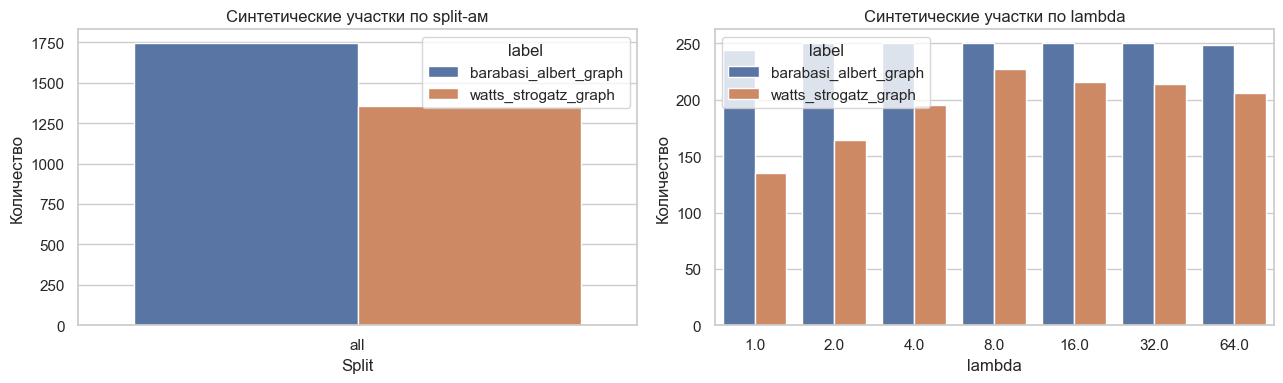

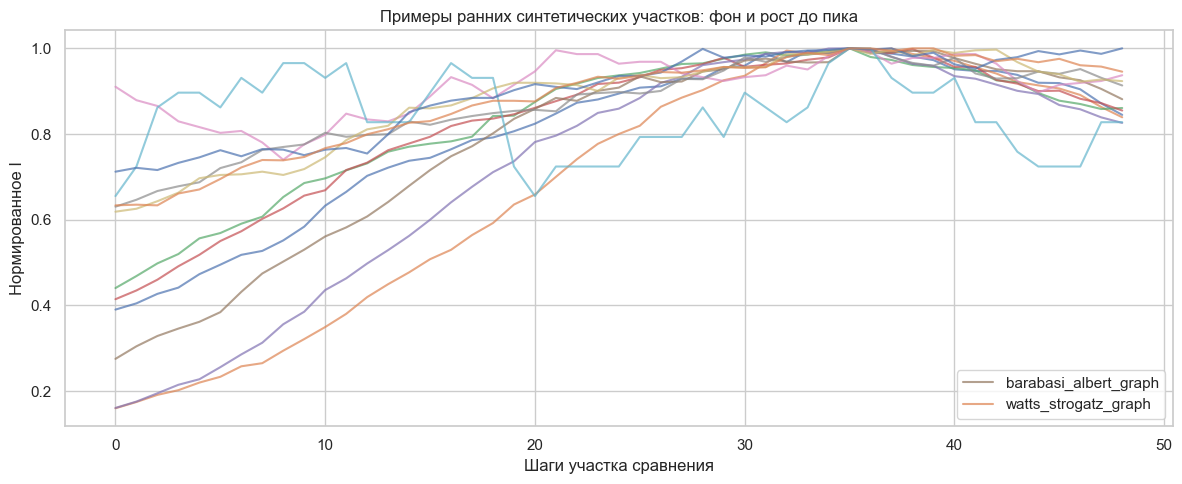

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=synthetic_features, x='source_split', hue='label', ax=axes[0])
axes[0].set_title('Синтетические участки по split-ам')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Количество')

sns.countplot(data=synthetic_features, x='lam', hue='label', ax=axes[1])
axes[1].set_title('Синтетические участки по lambda')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

sample_curves = synthetic_features.groupby('label', group_keys=False).sample(n=6, random_state=RANDOM_STATE)
plt.figure(figsize=(12, 5))
for row in sample_curves.itertuples(index=False):
    plt.plot(normalize_curve(row.comparison_curve), alpha=0.7, label=row.label)
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.title('Примеры ранних синтетических участков: фон и рост до пика')
plt.xlabel('Шаги участка сравнения')
plt.ylabel('Нормированное I')
plt.legend(unique.values(), unique.keys())
plt.tight_layout()
plt.show()

## 4. Признаки формы

Признаки считаются на нормированной кривой, чтобы модель сравнивала форму роста, а не масштаб эпидемии.

In [30]:
def curve_features(y):
    """Считает признаки формы нормированной кривой: пик, рост, ширину и площадь."""
    raw = clean_curve(y)
    n = int(raw.size)
    if n == 0:
        return {
            'n_points': 0, 'raw_peak': 0.0, 'peak_value': 0.0,
            'duration': 0.0, 'auc': 0.0, 'max_growth': 0.0, 'max_decline': 0.0,
            'width_at_half_max': 0.0, 'early_slope': 0.0, 'num_peaks': 0,
            'mean_value': 0.0, 'std_value': 0.0,
        }

    y_norm = normalize_curve(raw)
    peak_idx = int(np.argmax(y_norm))
    denom = max(n - 1, 1)
    diff = np.diff(y_norm) if n > 1 else np.array([0.0])
    half = np.where(y_norm >= 0.5)[0]

    # Ранний наклон считаем по первым 20% участка, но минимум по 3 точкам.
    early_window = max(3, min(n, int(np.ceil(n * 0.2))))
    early_y = y_norm[:early_window]
    early_slope = 0.0
    if early_window >= 2 and np.std(early_y) > 0:
        early_slope = float(np.polyfit(np.arange(early_window, dtype=float), early_y, 1)[0])

    # Локальные пики помогают отличать гладкий рост от более рваных участков.
    num_peaks = 0
    for i in range(1, n - 1):
        is_peak = y_norm[i] >= y_norm[i - 1] and y_norm[i] >= y_norm[i + 1]
        is_prominent = y_norm[i] - min(y_norm[i - 1], y_norm[i + 1]) >= 0.05
        num_peaks += int(is_peak and is_prominent)

    return {
        'n_points': n,
        'raw_peak': float(np.max(raw)),
        'peak_value': float(np.max(y_norm)),
        'duration': float(np.sum(y_norm > 0.05) / n),
        'auc': float(np.trapz(y_norm) / denom) if n > 1 else float(y_norm[0]),
        'max_growth': float(np.max(diff)) if diff.size else 0.0,
        'max_decline': float(abs(np.min(diff))) if diff.size else 0.0,
        'width_at_half_max': float((half[-1] - half[0] + 1) / n) if half.size else 0.0,
        'early_slope': early_slope,
        'num_peaks': int(num_peaks),
        'mean_value': float(np.mean(y_norm)),
        'std_value': float(np.std(y_norm)),
    }

feature_df = pd.DataFrame([curve_features(curve) for curve in synthetic_features['comparison_curve']])
synthetic_features = pd.concat([synthetic_features.reset_index(drop=True), feature_df], axis=1)

# Эти признаки завязаны на масштаб, длину ряда или процедуру выравнивания по пику,
# поэтому исключаем их из модели формы.
EXCLUDED_MODEL_FEATURES = ['n_points', 'raw_peak', 'peak_value', 'time_to_peak']
FEATURE_COLUMNS = list(feature_df.columns)
MODEL_FEATURE_COLUMNS = [column for column in FEATURE_COLUMNS if column not in EXCLUDED_MODEL_FEATURES]

print('Признаки модели:')
display(pd.Series(MODEL_FEATURE_COLUMNS, name='feature'))
display(synthetic_features[MODEL_FEATURE_COLUMNS + ['label']].head())

Признаки модели:


0             duration
1                  auc
2           max_growth
3          max_decline
4    width_at_half_max
5          early_slope
6            num_peaks
7           mean_value
8            std_value
Name: feature, dtype: object

,duration,auc,max_growth,max_decline,width_at_half_max,early_slope,num_peaks,mean_value,std_value,label
0,1.0,0.886343,0.046667,0.042222,1.000000,0.015044,0,0.883719,0.084686,barabasi_albert_graph
1,1.0,0.846792,0.048673,0.042035,1.000000,0.015339,0,0.844094,0.144512,barabasi_albert_graph
2,1.0,0.890370,0.037296,0.034965,1.000000,0.022434,0,0.888255,0.091074,barabasi_albert_graph
3,1.0,0.904180,0.051836,0.041037,1.000000,0.014752,2,0.902676,0.068533,barabasi_albert_graph
4,1.0,0.790084,0.047228,0.034908,0.938776,0.012271,0,0.788543,0.185023,barabasi_albert_graph


## 5. Как признаки разделяют классы

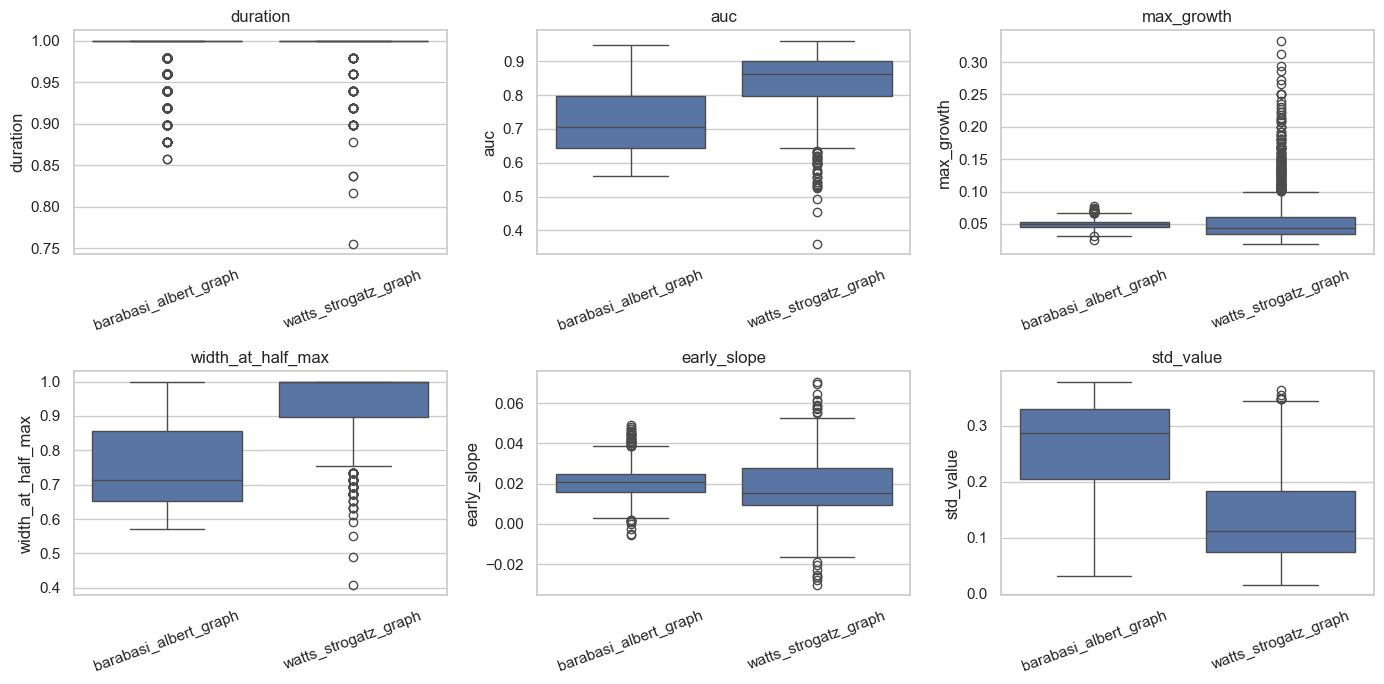

In [31]:
plot_features = ['duration', 'auc', 'max_growth', 'width_at_half_max', 'early_slope', 'std_value']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, feature in zip(axes.ravel(), plot_features):
    sns.boxplot(data=synthetic_features, x='label', y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Балансировка и обучение модели

Чтобы модель не училась на перекосах lambda или класса, сначала выравниваем страты label + lambda, а потом заново делим данные на train/validation/test.

In [32]:
work = synthetic_features.copy()
work['stratify_key'] = work[['label', 'lam']].astype(str).agg('|'.join, axis=1)
strata_counts = work['stratify_key'].value_counts().sort_index()
min_stratum_size = int(strata_counts.min())

balanced = pd.concat(
    [group.sample(n=min_stratum_size, random_state=RANDOM_STATE) for _, group in work.groupby('stratify_key')],
    ignore_index=True,
)

train_df, holdout_df = train_test_split(
    balanced,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=balanced['stratify_key'],
)

val_df, test_df = train_test_split(
    holdout_df,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=holdout_df['stratify_key'],
)

train_df = train_df.assign(split='train').copy()
val_df = val_df.assign(split='val').copy()
test_df = test_df.assign(split='test').copy()
final_splits = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Размеры страт до балансировки:')
display(strata_counts.rename('before_balance').reset_index())
print('Финальное распределение split-ов по классам:')
display(final_splits.groupby(['split', 'label']).size().unstack(fill_value=0))
print('Финальное распределение split-ов по классам и lambda:')
display(final_splits.groupby(['split', 'label', 'lam']).size().rename('n').reset_index())

Размеры страт до балансировки:


,stratify_key,before_balance
0,barabasi_albert_graph|1.0,244
1,barabasi_albert_graph|16.0,250
2,barabasi_albert_graph|2.0,250
3,barabasi_albert_graph|32.0,250
4,barabasi_albert_graph|4.0,250
5,barabasi_albert_graph|64.0,249
6,barabasi_albert_graph|8.0,250
7,watts_strogatz_graph|1.0,135
8,watts_strogatz_graph|16.0,216
9,watts_strogatz_graph|2.0,164


Финальное распределение split-ов по классам:


label,barabasi_albert_graph,watts_strogatz_graph
split,,
test,189,189
train,567,567
val,189,189


Финальное распределение split-ов по классам и lambda:


,split,label,lam,n
0,test,barabasi_albert_graph,1.0,27
1,test,barabasi_albert_graph,2.0,27
2,test,barabasi_albert_graph,4.0,27
3,test,barabasi_albert_graph,8.0,27
4,test,barabasi_albert_graph,16.0,27
5,test,barabasi_albert_graph,32.0,27
6,test,barabasi_albert_graph,64.0,27
7,test,watts_strogatz_graph,1.0,27
8,test,watts_strogatz_graph,2.0,27
9,test,watts_strogatz_graph,4.0,27


In [33]:
models = {
    'logistic_regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'random_forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ]),
}

model_rows = []
X_train = train_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_train = train_df['label']
X_val = val_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_val = val_df['label']

for model_name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    recalls = recall_score(y_val, val_pred, labels=model.classes_, average=None, zero_division=0)
    model_rows.append({
        'model': model_name,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
        'val_f1_macro': f1_score(y_val, val_pred, average='macro'),
        'val_min_class_recall': float(np.min(recalls)),
    })

model_scores = pd.DataFrame(model_rows).sort_values(
    ['val_min_class_recall', 'val_f1_macro', 'val_balanced_accuracy', 'val_accuracy'],
    ascending=False,
)

accepted_models = model_scores[model_scores['val_min_class_recall'] > MIN_CLASS_RECALL_FOR_ACCEPTANCE]
if accepted_models.empty:
    raise ValueError('Ни одна модель не прошла validation: у одного из классов recall равен нулю.')

best_model_name = accepted_models.iloc[0]['model']
best_model = models[best_model_name]

print(f'Лучшая модель: {best_model_name}')
display(model_scores)

Лучшая модель: random_forest


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,val_min_class_recall
1,random_forest,0.896825,0.896825,0.896819,0.888889
0,logistic_regression,0.854497,0.854497,0.854047,0.798942


## 7. Проверка на test

,test_accuracy,test_balanced_accuracy,test_macro_f1,test_min_class_recall
0,0.880952,0.880952,0.880885,0.857143


                       precision    recall  f1-score   support

barabasi_albert_graph       0.90      0.86      0.88       189
 watts_strogatz_graph       0.86      0.90      0.88       189

             accuracy                           0.88       378
            macro avg       0.88      0.88      0.88       378
         weighted avg       0.88      0.88      0.88       378



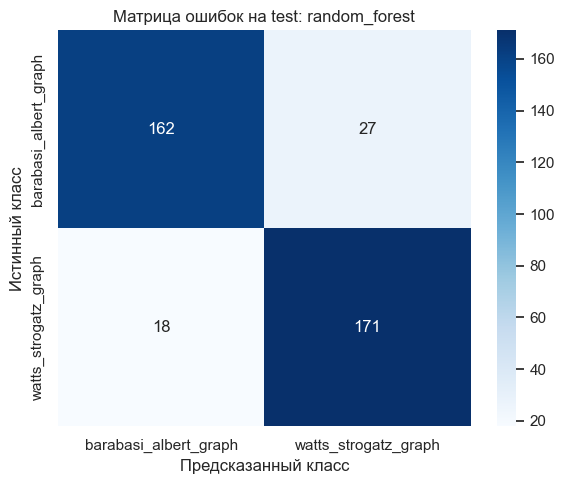

In [34]:
X_test = test_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_test = test_df['label']
test_pred = best_model.predict(X_test)
labels = list(best_model.classes_)
test_recalls = recall_score(y_test, test_pred, labels=labels, average=None, zero_division=0)

test_metrics = {
    'test_accuracy': accuracy_score(y_test, test_pred),
    'test_balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
    'test_macro_f1': f1_score(y_test, test_pred, average='macro'),
    'test_min_class_recall': float(np.min(test_recalls)),
}

if test_metrics['test_min_class_recall'] <= MIN_CLASS_RECALL_FOR_ACCEPTANCE:
    raise ValueError('Выбранная модель не прошла test: у одного из классов recall равен нулю.')

display(pd.DataFrame([test_metrics]))
print(classification_report(y_test, test_pred, labels=labels, zero_division=0))

cm = confusion_matrix(y_test, test_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Матрица ошибок на test: {best_model_name}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

## 8. Городские данные

Теперь читаем недельные городские ряды и сразу смотрим, какие города и годы доступны после 2009 года.

In [35]:
if not CITY_DATA_PATH.exists():
    raise FileNotFoundError(f'City data file not found. Checked paths: {CITY_DATA_PATH_CANDIDATES}')

if CITY_DATA_PATH.suffix.lower() in {'.xlsx', '.xls'}:
    city_df = pd.read_excel(CITY_DATA_PATH)
elif CITY_DATA_PATH.suffix.lower() == '.csv':
    city_df = pd.read_csv(CITY_DATA_PATH, delimiter=';')
else:
    raise ValueError(f'Unsupported city data file format: {CITY_DATA_PATH.suffix}')

required_city_columns = {'town_name', 'cld_year', 'week_number', 'wd_total', 'wda_total', 'qty_total'}
missing_city_columns = required_city_columns.difference(city_df.columns)
if missing_city_columns:
    raise ValueError(f'{CITY_DATA_PATH} is missing required columns: {sorted(missing_city_columns)}')

for column in ['cld_year', 'week_number', 'wd_total', 'qty_total']:
    city_df[column] = pd.to_numeric(city_df[column], errors='coerce')

city_df = (
    city_df[city_df['cld_year'] >= CITY_START_YEAR]
    .sort_values(['town_name', 'cld_year', 'week_number'])
    .reset_index(drop=True)
)

print(f'City data file: {CITY_DATA_PATH}')
print(f'Rows after {CITY_START_YEAR}: {len(city_df):,}')
print(f'Cities: {city_df["town_name"].nunique()}')

display(city_df.groupby('town_name').agg(
    rows=('wd_total', 'size'),
    non_missing_wd_total=('wd_total', lambda x: x.notna().sum()),
    first_year=('cld_year', 'min'),
    last_year=('cld_year', 'max'),
).reset_index())

City data file: c:\Users\annen\Documents\Projects\topology_influences_on_disease_spread\data\indices_in_big_cities.xlsx
Rows after 2010: 4,380
Cities: 12


,town_name,rows,non_missing_wd_total,first_year,last_year
0,Екатеринбург,365,313,2010,2016
1,Казань,365,313,2010,2016
2,Москва,365,313,2010,2016
3,Нижний_Новгород,365,313,2010,2016
4,Новосибирск,365,313,2010,2016
5,Омск,365,313,2010,2016
6,Пермь,365,313,2010,2016
7,Ростов-на-Дону,365,313,2010,2016
8,Самара,365,313,2010,2016
9,Санкт-Петербург,365,313,2010,2016


## 9. Первичный взгляд на городские ряды

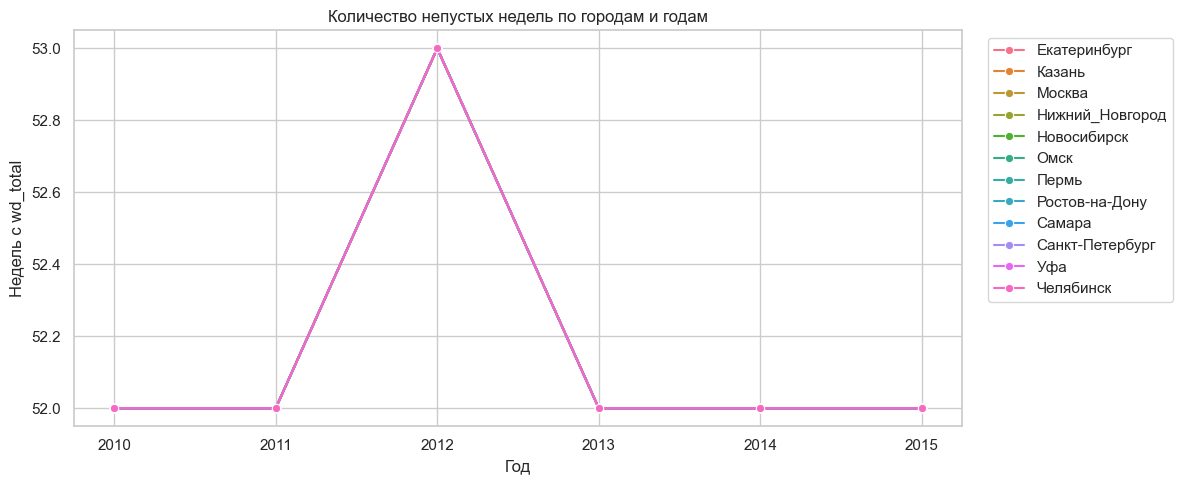

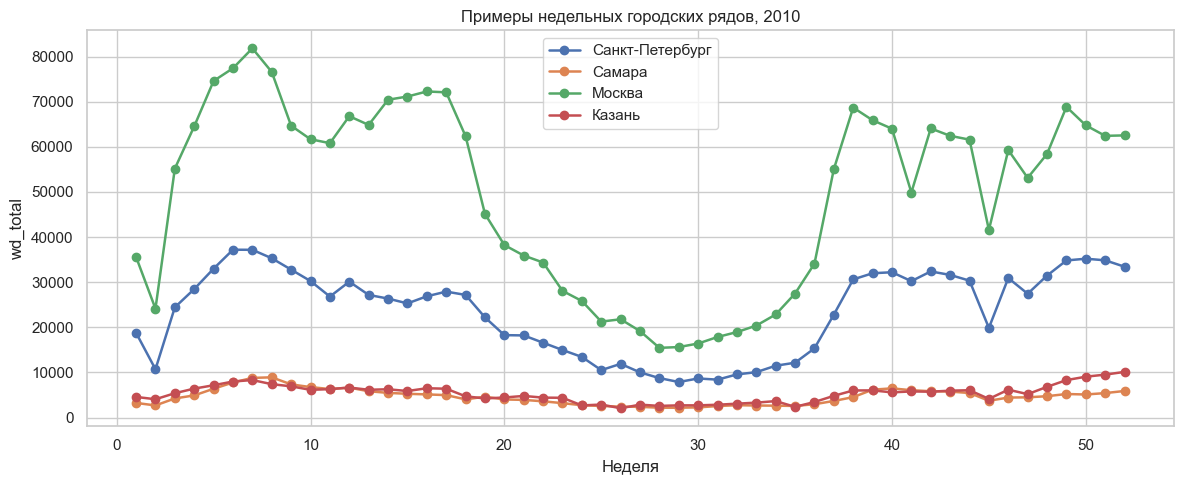

In [41]:
city_year_counts = city_df.dropna(subset=['wd_total']).groupby(['town_name', 'cld_year']).size().reset_index(name='weeks')

plt.figure(figsize=(12, 5))
sns.lineplot(data=city_year_counts, x='cld_year', y='weeks', hue='town_name', marker='o')
plt.title('Количество непустых недель по городам и годам')
plt.xlabel('Год')
plt.ylabel('Недель с wd_total')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

example_cities = ['Санкт-Петербург', 'Самара', 'Москва', 'Казань']
example_year = 2010
plt.figure(figsize=(12, 5))
for city in example_cities:
    example = city_df[(city_df['town_name'] == city) & (city_df['cld_year'] == example_year)]
    plt.plot(example['week_number'], example['wd_total'], marker='o', linewidth=1.8, label=city)
plt.title(f'Примеры недельных городских рядов, {example_year}')
plt.xlabel('Неделя')
plt.ylabel('wd_total')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Поиск городских волн

Для каждого города сглаживаем ряд, ищем локальные пики выше адаптивного порога и берём участок от небольшого фона перед ростом до пика.

In [42]:
def smooth_city_series(group):
    """Сглаживает недельный ряд города и переходит к доле заболевших, если есть население."""
    group = group.sort_values(['cld_year', 'week_number']).copy()
    y = group['wd_total'].astype(float)
    population = group['qty_total'].replace(0, np.nan).astype(float)
    if population.notna().sum() > 0:
        y = y / population
    y = y.interpolate(limit_direction='both')
    return y.rolling(window=5, center=True, min_periods=1).median().rolling(window=3, center=True, min_periods=1).mean().to_numpy(dtype=float)


def epidemic_segments(group):
    """Находит непрерывные интервалы, где wda_total помечен как эпидемия."""
    epidemic_mask = group['wda_total'].astype(str).isin(EPIDEMIC_MARKS).to_numpy()
    segments = []
    i = 0
    while i < len(epidemic_mask):
        if not epidemic_mask[i]:
            i += 1
            continue
        start = i
        while i + 1 < len(epidemic_mask) and epidemic_mask[i + 1]:
            i += 1
        end = i
        segments.append((start, end))
        i += 1
    return segments


city_wave_records = []
city_wave_curves = []
city_wave_issues = []

for city, group in city_df.groupby('town_name'):
    group = group.sort_values(['cld_year', 'week_number']).reset_index(drop=True)
    smoothed = smooth_city_series(group)
    valid = np.isfinite(smoothed) & (smoothed >= 0)

    if valid.sum() < CITY_WINDOW_POINTS or np.nanmax(smoothed[valid]) <= 0:
        city_wave_issues.append({'city': city, 'issue': 'not enough non-empty observations'})
        continue

    series = pd.Series(np.where(valid, smoothed, np.nan)).interpolate(limit_direction='both').to_numpy(dtype=float)
    waves = []

    for epidemic_start_idx, epidemic_end_idx in epidemic_segments(group):
        epidemic_segment = series[epidemic_start_idx:epidemic_end_idx + 1]
        if epidemic_segment.size == 0 or np.nanmax(epidemic_segment) <= 0:
            continue

        peak_idx = epidemic_start_idx + int(np.nanargmax(epidemic_segment))
        start_idx = peak_idx - CITY_WEEKS_BEFORE_PEAK
        end_exclusive = peak_idx + CITY_WEEKS_AFTER_PEAK

        if start_idx < 0 or end_exclusive > len(series):
            continue

        comparison_curve = series[start_idx:end_exclusive]
        if comparison_curve.size != CITY_WINDOW_POINTS or np.nanmax(comparison_curve) <= 0:
            continue

        waves.append({
            'city': city,
            'start_idx': start_idx,
            'end_idx': end_exclusive - 1,
            'peak_idx': peak_idx,
            'comparison_start_idx': start_idx,
            'comparison_end_idx': end_exclusive - 1,
            'epidemic_start_idx': epidemic_start_idx,
            'epidemic_end_idx': epidemic_end_idx,
            'peak_value': float(series[peak_idx]),
            'full_curve': comparison_curve,
            'comparison_curve': comparison_curve,
        })

    if not waves:
        city_wave_issues.append({'city': city, 'issue': 'no full fixed-length epidemic windows'})
        continue

    for wave_id, wave in enumerate(sorted(waves, key=lambda item: item['start_idx']), start=1):
        features = curve_features(wave['comparison_curve'])
        city_wave_records.append({
            **features,
            'city': city,
            'wave_id': wave_id,
            'start_year': int(group.loc[wave['start_idx'], 'cld_year']),
            'start_week': int(group.loc[wave['start_idx'], 'week_number']),
            'end_year': int(group.loc[wave['end_idx'], 'cld_year']),
            'end_week': int(group.loc[wave['end_idx'], 'week_number']),
            'peak_year': int(group.loc[wave['peak_idx'], 'cld_year']),
            'peak_week': int(group.loc[wave['peak_idx'], 'week_number']),
            'comparison_start_year': int(group.loc[wave['comparison_start_idx'], 'cld_year']),
            'comparison_start_week': int(group.loc[wave['comparison_start_idx'], 'week_number']),
            'comparison_end_year': int(group.loc[wave['comparison_end_idx'], 'cld_year']),
            'comparison_end_week': int(group.loc[wave['comparison_end_idx'], 'week_number']),
            'epidemic_start_year': int(group.loc[wave['epidemic_start_idx'], 'cld_year']),
            'epidemic_start_week': int(group.loc[wave['epidemic_start_idx'], 'week_number']),
            'epidemic_end_year': int(group.loc[wave['epidemic_end_idx'], 'cld_year']),
            'epidemic_end_week': int(group.loc[wave['epidemic_end_idx'], 'week_number']),
            'full_wave_n_points': len(wave['full_curve']),
            'peak_value_city_series': wave['peak_value'],
        })
        city_wave_curves.append({'city': city, 'wave_id': wave_id, 'curve': wave['comparison_curve']})

city_waves = pd.DataFrame(city_wave_records)
city_wave_issues = pd.DataFrame(city_wave_issues)

print(f'Found city waves: {len(city_waves)}')
if not city_waves.empty:
    display(city_waves.groupby('city').size().rename('n_waves').reset_index())
if not city_wave_issues.empty:
    display(city_wave_issues)

Found city waves: 42


,city,n_waves
0,Екатеринбург,5
1,Казань,5
2,Москва,1
3,Нижний_Новгород,4
4,Новосибирск,3
5,Омск,3
6,Пермь,4
7,Ростов-на-Дону,2
8,Самара,3
9,Санкт-Петербург,3


## 11. Визуализация найденных волн

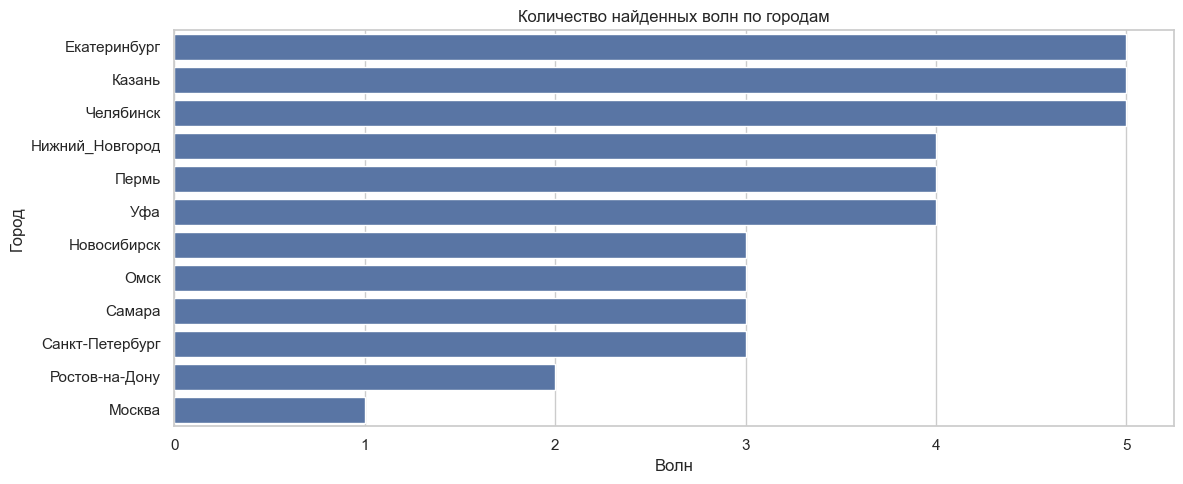

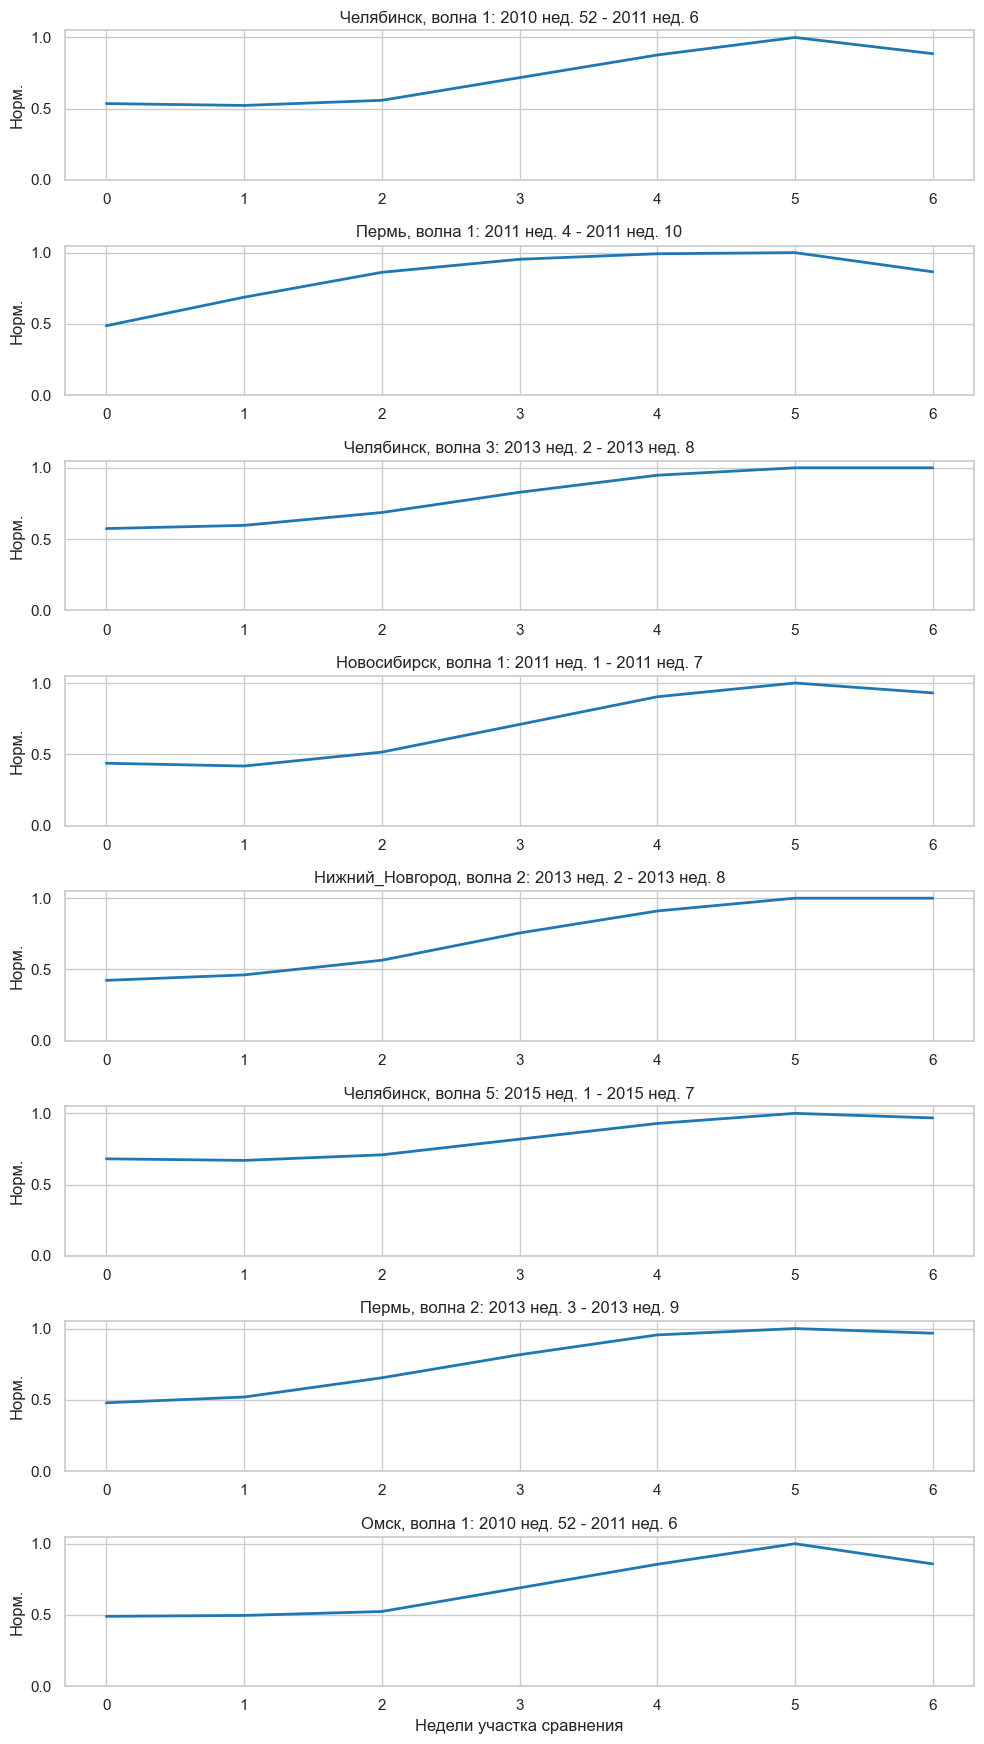

In [43]:
if city_waves.empty:
    print('Городские волны не найдены.')
else:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=city_waves, y='city', order=city_waves['city'].value_counts().index)
    plt.title('Количество найденных волн по городам')
    plt.xlabel('Волн')
    plt.ylabel('Город')
    plt.tight_layout()
    plt.show()

    example_waves = city_waves.sort_values('peak_value_city_series', ascending=False).head(8)
    curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

    fig, axes = plt.subplots(len(example_waves), 1, figsize=(10, max(4, 2.2 * len(example_waves))), sharex=False)
    if len(example_waves) == 1:
        axes = [axes]

    for ax, row in zip(axes, example_waves.itertuples(index=False)):
        curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
        ax.plot(curve, color='#1f77b4', linewidth=2)
        ax.set_ylim(0, 1.05)
        ax.set_title(f'{row.city}, волна {row.wave_id}: {row.comparison_start_year} нед. {row.comparison_start_week} - {row.comparison_end_year} нед. {row.comparison_end_week}')
        ax.set_ylabel('Норм.')

    axes[-1].set_xlabel('Недели участка сравнения')
    plt.tight_layout()
    plt.show()

## 12. Сравнение городских волн с синтетикой

Вероятности ниже — это сходство формы с синтетическими кривыми, а не доказанные метки реальной городской топологии.

In [44]:
city_X = city_waves[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
city_proba = best_model.predict_proba(city_X)
city_class = best_model.predict(city_X)
class_to_index = {label: idx for idx, label in enumerate(best_model.classes_)}

city_results = city_waves[[
    'city', 'wave_id',
    'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week',
    'start_year', 'start_week', 'end_year', 'end_week', 'peak_year', 'peak_week',
]].copy()

city_results['most_similar_synthetic_class'] = city_class
city_results['ba_shape_similarity'] = city_proba[:, class_to_index['barabasi_albert_graph']]
city_results['watts_shape_similarity'] = city_proba[:, class_to_index['watts_strogatz_graph']]
city_results['similarity_confidence'] = city_proba.max(axis=1)

duplicated_intervals = city_results.duplicated(
    ['city', 'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week'],
    keep=False,
)
if duplicated_intervals.any():
    display(city_results.loc[duplicated_intervals].sort_values(['city', 'start_year', 'start_week']))
    raise AssertionError('После удаления пересечений остались дублирующиеся городские интервалы сравнения.')

city_summary = city_results.groupby('city').agg(
    n_waves=('wave_id', 'count'),
    ba_like_share=('ba_shape_similarity', lambda x: np.mean(x >= 0.5)),
    watts_like_share=('watts_shape_similarity', lambda x: np.mean(x >= 0.5)),
    mean_ba_shape_similarity=('ba_shape_similarity', 'mean'),
    mean_watts_shape_similarity=('watts_shape_similarity', 'mean'),
    mean_similarity_confidence=('similarity_confidence', 'mean'),
).reset_index().sort_values('mean_ba_shape_similarity', ascending=False)

print('Сходство на уровне отдельных волн:')
display(city_results.sort_values(['city', 'wave_id']).head(30))
print('Сводка по городам:')
display(city_summary)

Сходство на уровне отдельных волн:


,city,wave_id,comparison_start_year,comparison_start_week,comparison_end_year,comparison_end_week,start_year,start_week,end_year,end_week,peak_year,peak_week,most_similar_synthetic_class,ba_shape_similarity,watts_shape_similarity,similarity_confidence
0,Екатеринбург,1,2010,45,2010,51,2010,45,2010,51,2010,50,watts_strogatz_graph,0.271205,0.728795,0.728795
1,Екатеринбург,2,2011,2,2011,8,2011,2,2011,8,2011,7,watts_strogatz_graph,0.088476,0.911524,0.911524
2,Екатеринбург,3,2013,1,2013,7,2013,1,2013,7,2013,6,watts_strogatz_graph,0.331827,0.668173,0.668173
3,Екатеринбург,4,2014,5,2014,11,2014,5,2014,11,2014,10,watts_strogatz_graph,0.126702,0.873298,0.873298
4,Екатеринбург,5,2015,2,2015,8,2015,2,2015,8,2015,7,watts_strogatz_graph,0.017208,0.982792,0.982792
5,Казань,1,2010,46,2010,52,2010,46,2010,52,2010,51,watts_strogatz_graph,0.219438,0.780562,0.780562
6,Казань,2,2011,2,2011,8,2011,2,2011,8,2011,7,watts_strogatz_graph,0.176506,0.823494,0.823494
7,Казань,3,2012,51,2013,4,2012,51,2013,4,2013,3,watts_strogatz_graph,0.045253,0.954747,0.954747
8,Казань,4,2014,6,2014,12,2014,6,2014,12,2014,11,watts_strogatz_graph,0.383029,0.616971,0.616971
9,Казань,5,2015,5,2015,11,2015,5,2015,11,2015,10,watts_strogatz_graph,0.408604,0.591396,0.591396


Сводка по городам:


,city,n_waves,ba_like_share,watts_like_share,mean_ba_shape_similarity,mean_watts_shape_similarity,mean_similarity_confidence
7,Ростов-на-Дону,2,0.5,0.5,0.500838,0.499162,0.578734
4,Новосибирск,3,0.0,1.0,0.295738,0.704262,0.704262
10,Уфа,4,0.0,1.0,0.295186,0.704814,0.704814
11,Челябинск,5,0.0,1.0,0.293164,0.706836,0.706836
6,Пермь,4,0.0,1.0,0.290121,0.709879,0.709879
8,Самара,3,0.0,1.0,0.289491,0.710509,0.710509
9,Санкт-Петербург,3,0.0,1.0,0.262631,0.737369,0.737369
1,Казань,5,0.0,1.0,0.246566,0.753434,0.753434
0,Екатеринбург,5,0.0,1.0,0.167084,0.832916,0.832916
3,Нижний_Новгород,4,0.0,1.0,0.151240,0.848760,0.848760


## 13. Итоговые графики

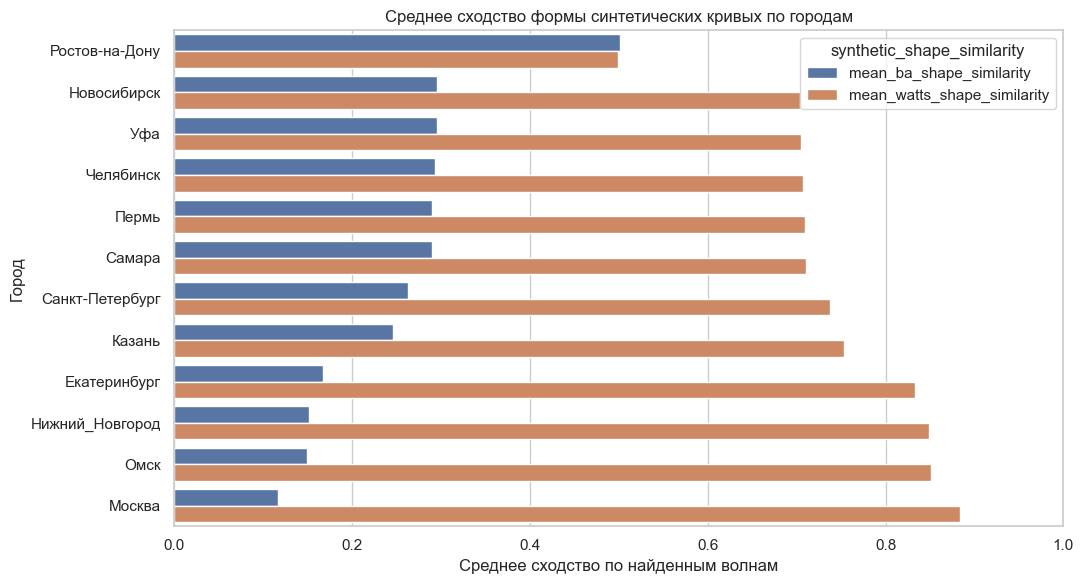

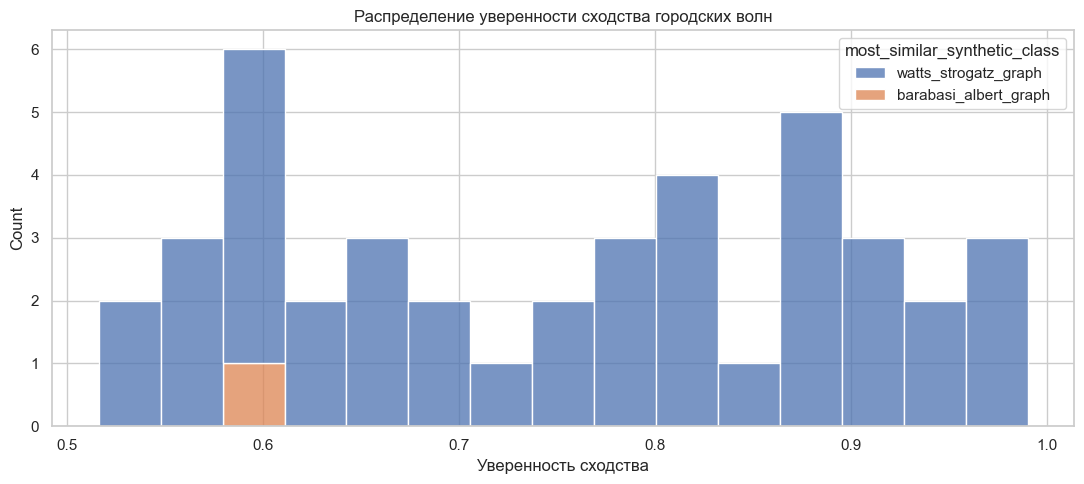

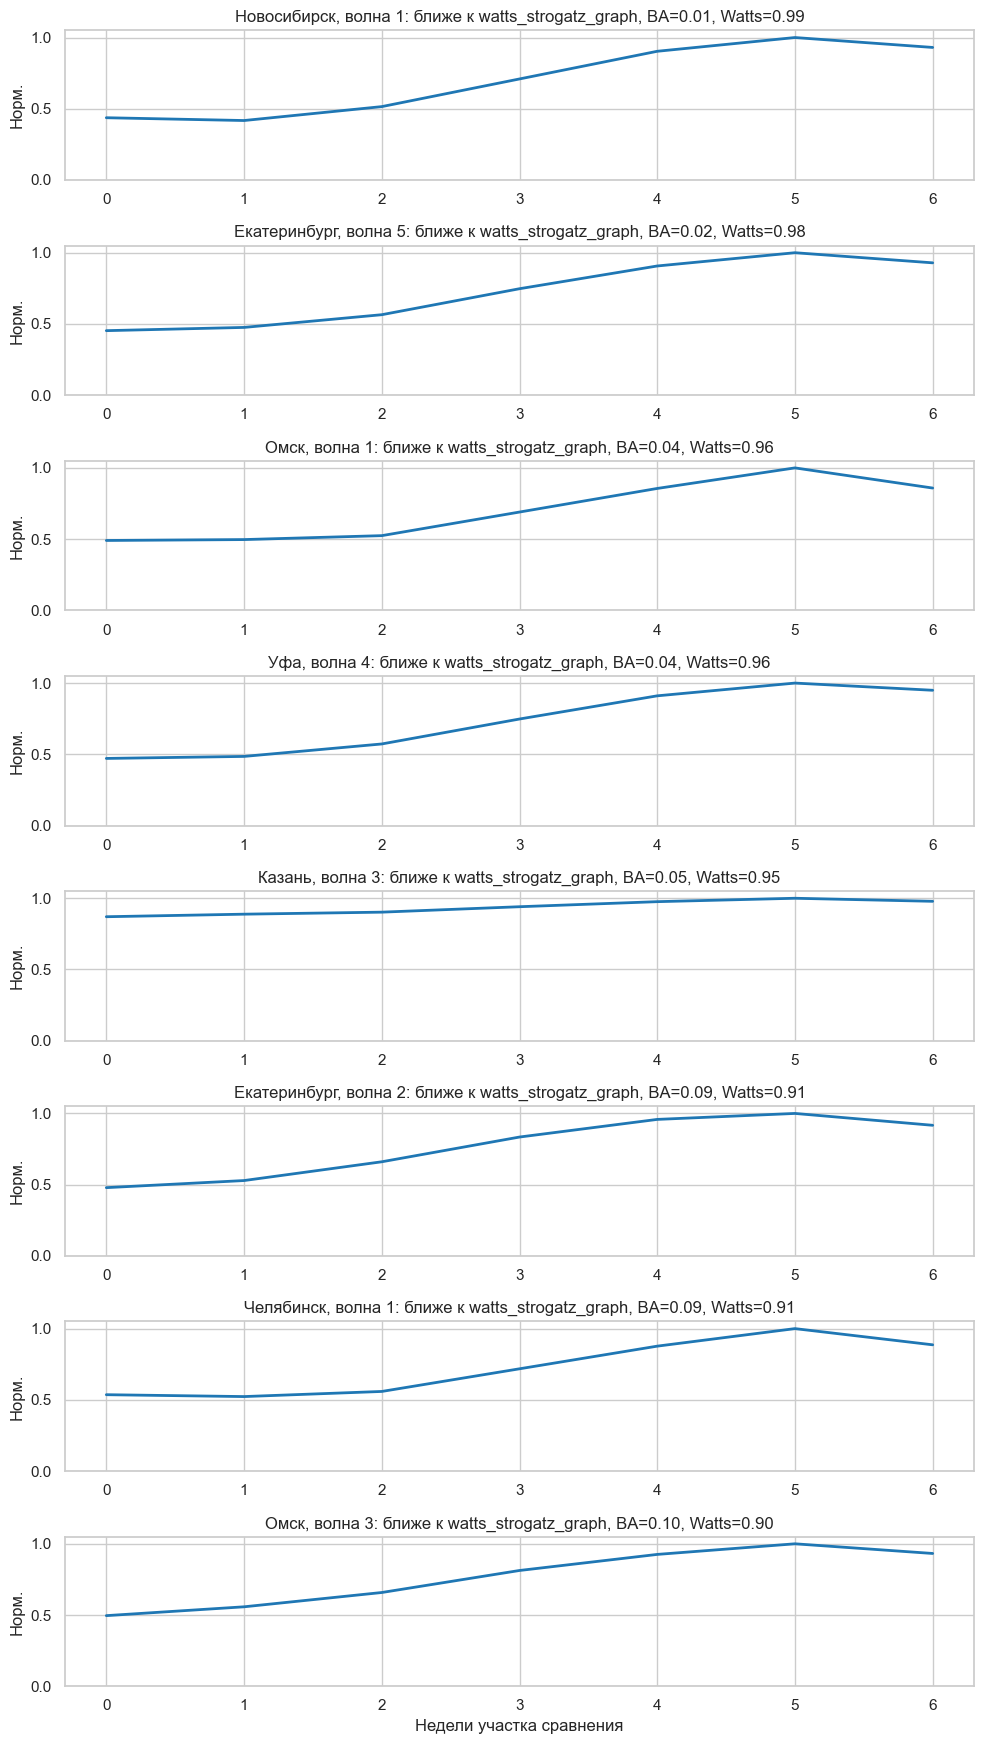

In [45]:
plot_df = city_summary.melt(
    id_vars='city',
    value_vars=['mean_ba_shape_similarity', 'mean_watts_shape_similarity'],
    var_name='synthetic_shape_similarity',
    value_name='mean_similarity',
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x='mean_similarity', y='city', hue='synthetic_shape_similarity')
plt.title('Среднее сходство формы синтетических кривых по городам')
plt.xlabel('Среднее сходство по найденным волнам')
plt.ylabel('Город')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.histplot(data=city_results, x='similarity_confidence', hue='most_similar_synthetic_class', bins=15, multiple='stack')
plt.title('Распределение уверенности сходства городских волн')
plt.xlabel('Уверенность сходства')
plt.tight_layout()
plt.show()

top_examples = city_results.sort_values('similarity_confidence', ascending=False).head(8)
curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

fig, axes = plt.subplots(len(top_examples), 1, figsize=(10, max(4, 2.2 * len(top_examples))), sharex=False)
if len(top_examples) == 1:
    axes = [axes]

for ax, row in zip(axes, top_examples.itertuples(index=False)):
    curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
    ax.plot(curve, color='#1f77b4', linewidth=2)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f'{row.city}, волна {row.wave_id}: ближе к {row.most_similar_synthetic_class}, '
        f'BA={row.ba_shape_similarity:.2f}, Watts={row.watts_shape_similarity:.2f}'
    )
    ax.set_ylabel('Норм.')

axes[-1].set_xlabel('Недели участка сравнения')
plt.tight_layout()
plt.show()

## 14. Как читать результат

- Модель обучена только на форме раннего участка синтетических кривых: небольшой фон перед ростом и рост до пика.
- ba_shape_similarity и watts_shape_similarity показывают сходство городской волны с двумя синтетическими классами.
- Это не прямое восстановление городской сетевой топологии, а аккуратное сравнение формы наблюдаемой волны с формами, полученными в симуляциях.